# Unsupervised Anomaly Detection (Supplementary Analysis)

**Why this notebook exists:** The core deliverable of this project is the supervised fraud detection model (XGBoost, threshold 0.82), selected and validated in Notebooks 3–7. This notebook is a deliberate, scoped side investigation — it does not feed into or change that model selection.

**Real-world motivation:** Supervised fraud detection requires labeled fraud examples to train on. In practice, banks regularly face situations without reliable labels yet — a new product line, a new market, or a newly observed fraud pattern with no historical tagging. Unsupervised anomaly detection is one of the few viable approaches in exactly that "cold-start" scenario, since it requires no fraud labels at all.

**What this notebook investigates:**
- How much fraud can Isolation Forest (an unsupervised method) detect without ever seeing a fraud label during training?
- How much do its flagged transactions overlap with the supervised model's predictions?
- Does unsupervised detection surface any fraud the supervised model misses — i.e., does it add meaningful incremental value on top of the main model?

This is exploratory and supplementary. Conclusions here inform how anomaly detection might complement the deployed model in a cold-start scenario, but do not alter the model selection made earlier in this project.

In [1]:
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import pickle
import os

### 2. Load Processed Data

We load:
- Scaled training data (used to fit Isolation Forest — no labels needed)
- Test data for evaluation
- True fraud labels (used strictly for evaluation, never for training the Isolation Forest itself)

Test data is used here as a one-time diagnostic comparison rather than a repeated decision loop, consistent with how the test set is used once and only once for final reporting elsewhere in this project (see Notebook 5).

In [2]:
# 2. Load preprocessed train and test data + scaler
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
PROCESSED_PATH = os.path.join(PROJECT_ROOT, "data", "processed")  # note: corrected casing
PLOTS_DIR = os.path.join(PROJECT_ROOT, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

X_train = pd.read_csv(f"{PROCESSED_PATH}/X_train_scaled_original.csv")
X_test = pd.read_csv(f"{PROCESSED_PATH}/X_test.csv")
y_test = pd.read_csv(f"{PROCESSED_PATH}/y_test.csv")

with open(f"{PROCESSED_PATH}/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

### 3. Train Isolation Forest

Isolation Forest is trained on the scaled training data.

Unlike supervised models, it does not use fraud labels.  
It learns patterns of normal behaviour and flags rare deviations as anomalies.
**Note on the `contamination` parameter:** `contamination=0.002` is set close to 
the known fraud rate in this dataset (~0.17%), giving Isolation Forest a 
reasonable prior on how many anomalies to expect. This is only possible here 
because the fraud rate happens to be known in advance from the labeled data. 
In a genuine cold-start scenario — the real-world case this notebook is meant 
to illustrate — the true anomaly rate would be unknown, and `contamination` 
would need to be estimated from domain knowledge or tuned via a separate 
validation process. This is a simplification specific to this demonstration, 
not something that would carry over directly to a true label-free deployment.


In [3]:
# 3. Fit Isolation Forest on training data (without labels)

# We use a random state for reproducibility
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.002,  # approximate fraction of outliers in training set
    random_state=42
)

iso_forest.fit(X_train)

,n_estimators,200
,max_samples,'auto'
,contamination,0.002
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


### 4. Score Test Data for Anomalies

Isolation Forest produces:

- An anomaly score (lower = more anomalous)
- A binary anomaly flag

We convert predictions into:

- 1 = anomaly (fraud-like)
- 0 = normal


In [4]:
# 4. Score test set for anomalies

# The decision_function gives anomaly scores
# The lower the score, the more anomalous
anomaly_scores = iso_forest.decision_function(X_test)
anomaly_flags = iso_forest.predict(X_test)
# Convert to 0/1: 1 = anomaly (fraud-like), 0 = normal
anomaly_flags = np.where(anomaly_flags == -1, 1, 0)

# Create dataframe for easy comparison
unsupervised_df = X_test.copy()
unsupervised_df['Anomaly_Flag'] = anomaly_flags
unsupervised_df['Anomaly_Score'] = anomaly_scores
unsupervised_df['Actual_Fraud'] = y_test['Target']

### 5. Load Final Supervised Model (XGBoost, from Notebook 4)

The final selected model (XGBoost, corrected for SMOTE-in-CV leakage) is loaded, and predictions are generated using the actual deployed threshold (0.82) from Notebook 5 — not an arbitrary default of 0.5. Comparing against the wrong threshold would misrepresent how the supervised model actually behaves in deployment.

In [5]:
# 5. Load final supervised model (XGBoost)
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")

with open(os.path.join(MODELS_DIR, "tuned_models_latest.pkl"), "rb") as f:
    tuned_models = pickle.load(f)

supervised_model = tuned_models["XGBoost"]
FINAL_THRESHOLD = 0.82

# Generate predictions on test set at the ACTUAL deployed threshold
supervised_probs = supervised_model.predict_proba(X_test)[:, 1]
supervised_preds = (supervised_probs >= FINAL_THRESHOLD).astype(int)

unsupervised_df['Supervised_Pred'] = supervised_preds

### 6. Categorize Detection Overlap

Each transaction is categorized into one of four groups:
- **Both** → flagged by supervised and unsupervised
- **Supervised only**
- **Unsupervised only**
- **Neither**

This identifies whether Isolation Forest provides additional signal beyond 
what the deployed XGBoost model already detects.

In [6]:
# 6. Categorize overlap vs unique flags

def categorize(row):
    if row['Supervised_Pred'] == 1 and row['Anomaly_Flag'] == 1:
        return 'Both'
    elif row['Supervised_Pred'] == 1:
        return 'Supervised only'
    elif row['Anomaly_Flag'] == 1:
        return 'Unsupervised only'
    else:
        return 'Neither'

unsupervised_df['Category'] = unsupervised_df.apply(categorize, axis=1)

### 7. Detection Category Counts

Raw transaction counts per category. Note the threshold change from 0.5 to 0.82 will shift these counts compared to an earlier version of this analysis, since fewer transactions now qualify as "Supervised only" or "Both" at the stricter, actual deployed threshold.

In [7]:
# 7️. Count transactions in each category

category_counts = unsupervised_df['Category'].value_counts()
category_counts

Category
Neither              56782
Unsupervised only       90
Supervised only         56
Both                    34
Name: count, dtype: int64

### Observation

* The majority of transactions are classified as "Neither", which is expected given class imbalance.
* Only a small number are flagged by both models.
* Unsupervised-only detections are limited, suggesting minimal unique signal.

### 8. Visual Comparison of Detection Categories

A barplot visualizes the overlap structure across the four categories.

C:\Users\mail2\AppData\Local\Temp\ipykernel_28664\1967698617.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


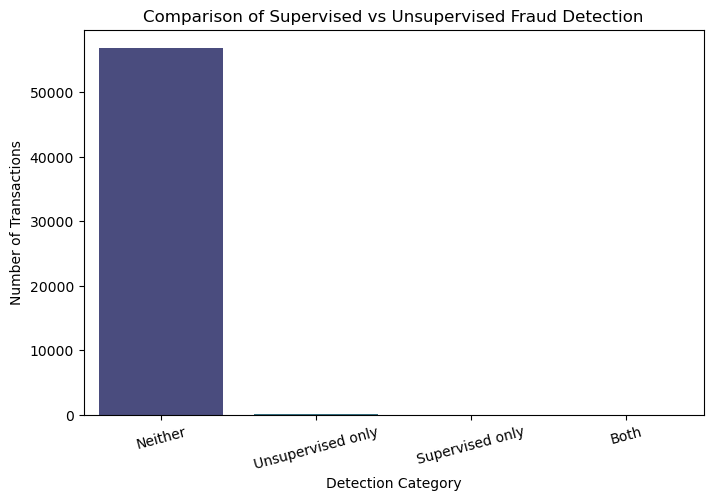

In [8]:
# 8️. Visualize overlap using barplot

plt.figure(figsize=(8,5))
sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")
plt.title("Comparison of Supervised vs Unsupervised Fraud Detection")
plt.ylabel("Number of Transactions")
plt.xlabel("Detection Category")
plt.xticks(rotation=15)
plt.savefig(os.path.join(PLOTS_DIR, "supervised_vs_unsupervised_overlap.png"),dpi=300, bbox_inches="tight")
plt.show()

### 9. Fraud Capture by Category

The proportion of total fraud cases captured in each category — more informative than raw counts, since fraud is rare and raw counts alone can be misleading.

In [9]:
# 9️. Insight: fraction of actual fraud captured in each category

fraud_by_category = unsupervised_df.groupby('Category')['Actual_Fraud'].sum()
total_fraud = y_test['Target'].sum()
fraud_fraction = fraud_by_category / total_fraud
fraud_fraction

Category
Both                 0.316327
Neither              0.173469
Supervised only      0.500000
Unsupervised only    0.010204
Name: Actual_Fraud, dtype: float64

### Interpretation

More than half of fraud cases are captured by the supervised model alone.

Approximately 30% are detected by both methods.

Only a very small fraction of fraud (around 2%) is identified exclusively by the unsupervised model.

This indicates that most meaningful fraud detection signal comes from supervised learning.


### 9b. False Positive Comparison

Fraud-capture percentage alone doesn't tell the full story — this project's broader approach (Notebooks 5 and 7) treats false positives as a real cost, not just a side effect. This section applies that same lens to Isolation Forest, comparing how many false alarms each method generates alongside how much fraud it catches.

In [10]:
# ---9b. Isolation Forest's own false positive rate, for consistency with the rest 
# of this project's cost-aware approach (Notebooks 5, 7) ---

fp_unsupervised = ((unsupervised_df['Anomaly_Flag'] == 1) & (unsupervised_df['Actual_Fraud'] == 0)).sum()
tp_unsupervised = ((unsupervised_df['Anomaly_Flag'] == 1) & (unsupervised_df['Actual_Fraud'] == 1)).sum()

fp_supervised = ((unsupervised_df['Supervised_Pred'] == 1) & (unsupervised_df['Actual_Fraud'] == 0)).sum()
tp_supervised = ((unsupervised_df['Supervised_Pred'] == 1) & (unsupervised_df['Actual_Fraud'] == 1)).sum()

print(f"Isolation Forest -> TP: {tp_unsupervised}, FP: {fp_unsupervised}")
print(f"XGBoost (supervised) -> TP: {tp_supervised}, FP: {fp_supervised}")

Isolation Forest -> TP: 32, FP: 92
XGBoost (supervised) -> TP: 80, FP: 10


### Observations

Isolation Forest catches substantially less fraud (32 vs. 80) while generating far more false alarms (92 vs. 10) than the supervised XGBoost model. This is a meaningful, quantified illustration of the trade-off named earlier: Isolation Forest has no notion of "fraud" specifically — it flags any statistically unusual transaction, which inevitably includes legitimate but atypical spending behavior alongside genuine fraud.

In cost terms (using the same dollar-weighted framework from Notebook 5), Isolation Forest's 9x higher false-positive count would translate directly into substantially higher operational cost from unnecessary investigations, on top of catching less than half the fraud XGBoost catches. This reinforces the "Practical takeaway" below: unsupervised anomaly detection is a reasonable fallback when no labels exist, but it comes at a real, quantifiable cost compared to supervised learning once labels are available.

### 10. Anomaly Score Distribution

We visualise the anomaly score distribution for:

- Fraud transactions
- Legitimate transactions
This helps assess whether anomaly scores meaningfully separate the two groups.

Visualizing whether Isolation Forest's anomaly scores meaningfully separate fraud from legitimate transactions, independent of any fixed threshold.


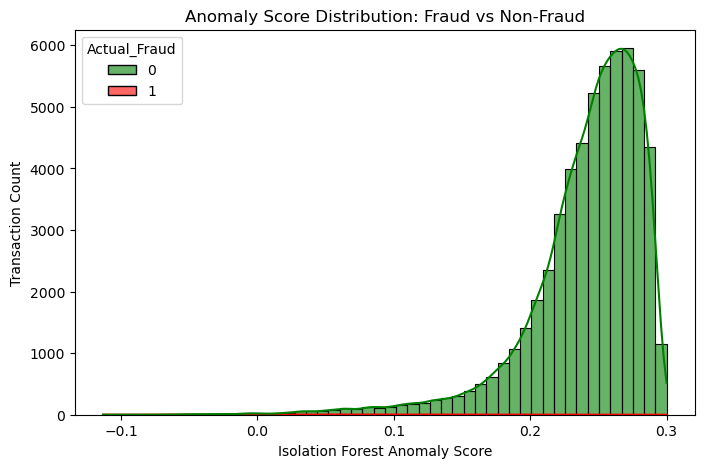

In [11]:
# 10. Optional: visualize anomaly score distribution for actual fraud vs non-fraud

plt.figure(figsize=(8,5))
sns.histplot(data=unsupervised_df, x='Anomaly_Score', hue='Actual_Fraud',
             bins=50, palette={0:'green', 1:'red'}, alpha=0.6, kde=True)
plt.title("Anomaly Score Distribution: Fraud vs Non-Fraud")
plt.xlabel("Isolation Forest Anomaly Score")
plt.ylabel("Transaction Count")
plt.savefig(os.path.join(PLOTS_DIR, "anomaly_score_distribution.png"),dpi=300, bbox_inches="tight")
plt.show()


### Final Interpretation

At the actual deployed threshold (0.82), the supervised XGBoost model captures 81.6% of all fraud cases (50.0% independently, plus 31.6% also flagged by Isolation Forest). Isolation Forest — trained with no fraud labels at all — contributes only 1.0% unique detection signal beyond what the supervised model already finds, reinforcing that it is not a substitute for the deployed supervised model in this labeled setting.

Compared to an earlier version of this analysis at the default threshold (0.5), moving to the actual deployed threshold (0.82) shows the expected trade-off: "Supervised only" detection dropped slightly (55.1% → 50.0%) and "Neither" (fraud missed by both methods) rose (12.2% → 17.3%). This is consistent with Notebook 5's cost-based threshold selection, which deliberately accepted a somewhat more conservative detection profile in exchange for minimizing overall expected dollar cost — this notebook's results are simply reflecting that same trade-off from a different analytical angle.

**Practical takeaway:** in a setting with reliable fraud labels — the case for this project — supervised learning is clearly the stronger approach, both in fraud capture (80 vs. 32 true positives) and false-alarm control (10 vs. 92 false positives). This project's model selection (Notebooks 3–5) is unaffected by this finding. Unsupervised anomaly detection remains a relevant complementary tool specifically for cold-start scenarios where labels aren't yet available, or as an exploratory signal to surface previously unseen fraud patterns for human review — but the false-positive cost shown here makes clear it is not a drop-in replacement for a well-labeled supervised approach.